# Анализ тональности текстов с использованием нейронных сетей

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, precision_score, recall_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 10

## Данные для анализа тональности

In [3]:
sentiment_data = {
    "text": [
        # --- позитив (1) ---
        "Отличный фильм, очень понравился!",
        "Прекрасная книга, рекомендую всем прочитать.",
        "Качественный товар, доволен покупкой.",
        "Замечательный сервис, быстро и профессионально.",
        "Потрясающий ресторан, вкусная еда и уютная атмосфера.",
        "Великолепный спектакль, получил массу удовольствия.",
        "Отличное приложение, удобный интерфейс.",
        "Прекрасный отель, комфортные номера и хороший завтрак.",
        "Замечательный преподаватель, интересные лекции.",
        "Потрясающая музыка, слушаю постоянно.",
        "Отличный телефон, все работает быстро.",
        "Прекрасный подарок, очень доволен.",
        "Качественный кофе, ароматный и вкусный.",
        "Замечательный парк, красивая природа.",
        "Потрясающий концерт, незабываемые эмоции.",
        # --- негатив (0) ---
        "Ужасный фильм, полная потеря времени.",
        "Плохая книга, скучно и неинтересно.",
        "Низкое качество товара, очень разочарован.",
        "Плохой сервис, долго ждал и ничего не получил.",
        "Отвратительный ресторан, невкусная еда.",
        "Скучный спектакль, не рекомендую.",
        "Плохое приложение, постоянно глючит.",
        "Ужасный отель, грязные номера и плохое обслуживание.",
        "Скучный преподаватель, неинтересные лекции.",
        "Плохая музыка, не понравилась.",
        "Плохой телефон, постоянно зависает.",
        "Разочаровался в подарке, не то что ожидал.",
        "Плохой кофе, безвкусный и холодный.",
        "Запущенный парк, грязно и неухоженно.",
        "Скучный концерт, не оправдал ожиданий.",
        # --- нейтрал (2) ---
        "Обычный фильм, ничего особенного.",
        "Стандартная книга, читается нормально.",
        "Обычный товар, соответствует описанию.",
        "Нормальный сервис, без особых претензий.",
        "Обычный ресторан, стандартное меню.",
        "Средний спектакль, можно посмотреть.",
        "Обычное приложение, работает как надо.",
        "Стандартный отель, без изысков.",
        "Обычный преподаватель, стандартные лекции.",
        "Средняя музыка, ничего особенного.",
    ],
    "sentiment": [
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
    ]
}

df = pd.DataFrame(sentiment_data)
print("Всего отзывов:", len(df))
print("\nРаспределение классов:")
print(df["sentiment"].value_counts().sort_index())

Всего отзывов: 40

Распределение классов:
sentiment
0    15
1    15
2    10
Name: count, dtype: int64


## Бинарная классификация

In [4]:
df_binary = df[df["sentiment"] != 2]
print(f"Данные для бинарной классификации: {len(df_binary)} отзывов")

vectorizer = TfidfVectorizer(max_features=100)
X = vectorizer.fit_transform(df_binary["text"]).toarray()
y = df_binary["sentiment"].values

print(f"Размерность признакового пространства: {X.shape}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Данные для бинарной классификации: 30 отзывов
Размерность признакового пространства: (30, 96)
Train: 21, Test: 9


In [5]:
model = Sequential([
    Dense(32, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Архитектура модели:")
model.summary()

Архитектура модели:


C:\Users\danii\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,649 (14.25 KB)

 Trainable params: 3,649 (14.25 KB)

 Non-trainable params: 0 (0.00 B)

## Обучение модели

In [6]:
history = model.fit(
    X_train, y_train,
    epochs=80,
    batch_size=8,
    validation_split=0.2,
    verbose=1
)

Epoch 1/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 181ms/step - accuracy: 0.5625 - loss: 0.6608 - val_accuracy: 0.6000 - val_loss: 1.1718
Epoch 2/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.5625 - loss: 0.6092 - val_accuracy: 0.6000 - val_loss: 1.1568
Epoch 3/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.6875 - loss: 0.5591 - val_accuracy: 0.6000 - val_loss: 1.1451
Epoch 4/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.6875 - loss: 0.5136 - val_accuracy: 0.6000 - val_loss: 1.1375
Epoch 5/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.7500 - loss: 0.4785 - val_accuracy: 0.6000 - val_loss: 1.1295
Epoch 6/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8125 - loss: 0.4462 - val_accuracy: 0.6000 - val_loss: 1.1221
Epoch 7/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8125 - loss: 0.4158 - val_accuracy: 0.6000 - val_loss: 1.1163
Epoch 8/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9375 - loss: 0.3875 - val_accuracy: 0.6000 - val_loss: 1.1130

## Предсказание и оценка качества

In [7]:
y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()


print(f"РЕЗУЛЬТАТЫ БИНАРНОЙ КЛАССИФИКАЦИИ\n")

print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
РЕЗУЛЬТАТЫ БИНАРНОЙ КЛАССИФИКАЦИИ

F1-Score:  0.5714
Precision: 0.5000
Recall:    0.6667


## Визуализация обучения

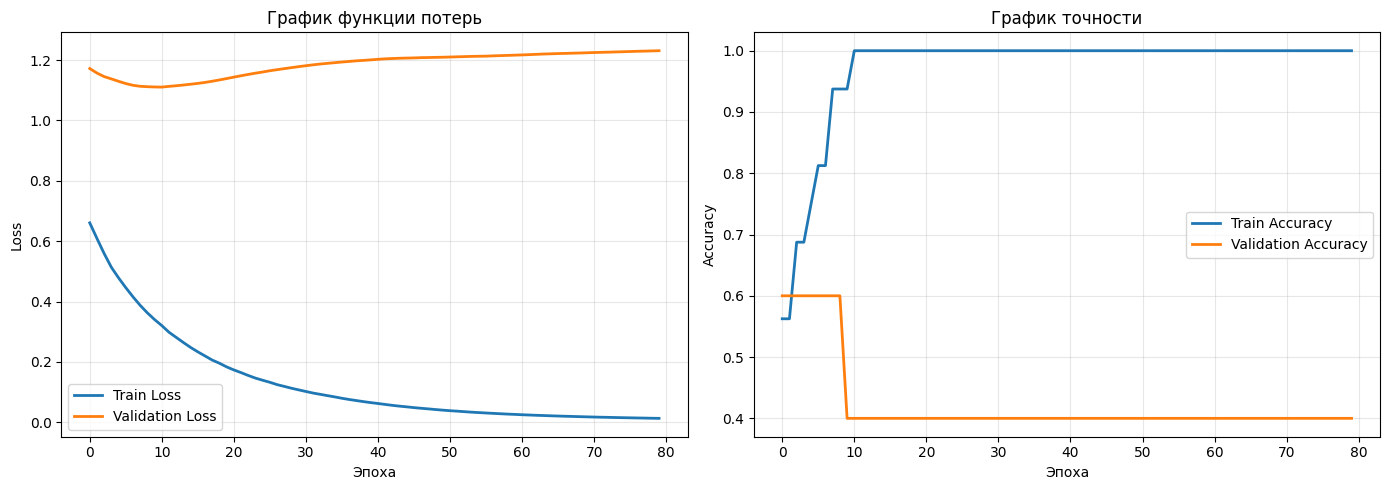

In [8]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss", linewidth=2)
plt.plot(history.history["val_loss"], label="Validation Loss", linewidth=2)
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("График функции потерь")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Train Accuracy", linewidth=2)
plt.plot(history.history["val_accuracy"], label="Validation Accuracy", linewidth=2)
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("График точности")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Модель показывает слабые результаты с явным переобучением. Precision 50% означает, что половина предсказаний модели оказывается ошибочной (много ложных срабатываний), а Recall 67% говорит, что модель находит только 2 из 3 реальных положительных случаев. F1-Score 57% подтверждает посредственное качество классификации.

## Применение Dropout и Early Stopping
- **Dropout** — случайное отключение нейронов во время обучения для предотвращения переобучения
- **Early Stopping** — остановка обучения при отсутствии улучшений на валидации

In [30]:
model2 = Sequential([
    Dense(32, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(16, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid"),
])

model2.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss", 
    patience=20, 
    restore_best_weights=True 
)

print("Модель с регуляризацией:")
model2.summary()

Модель с регуляризацией:


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_54 (Dense)                     │ (None, 32)                  │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_55 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_56 (Dense)                     │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,649 (14.25 KB)

 Trainable params: 3,649 (14.25 KB)

 Non-trainable params: 0 (0.00 B)

# Обучение с Early Stopping

In [31]:
history2 = model2.fit(
    X_train, y_train,
    epochs=150,
    batch_size=8,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

print(f"\nОбучение остановилось на эпохе: {len(history2.history['loss'])}")

Epoch 1/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 192ms/step - accuracy: 0.5000 - loss: 0.9765 - val_accuracy: 0.4000 - val_loss: 1.0483
Epoch 2/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.5625 - loss: 0.8277 - val_accuracy: 0.4000 - val_loss: 1.0353
Epoch 3/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.3750 - loss: 0.9990 - val_accuracy: 0.4000 - val_loss: 1.0220
Epoch 4/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.6875 - loss: 0.7072 - val_accuracy: 0.4000 - val_loss: 1.0082
Epoch 5/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5625 - loss: 0.7270 - val_accuracy: 0.6000 - val_loss: 0.9964
Epoch 6/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5625 - loss: 0.7787 - val_accuracy: 0.6000 - val_loss: 0.9875
Epoch 7/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5000 - loss: 0.8183 - val_accuracy: 0.6000 - val_loss: 0.9832
Epoch 8/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5625 - loss: 0.6701 - val_accuracy: 0.6000 - val_loss

## Оценка качества

In [32]:
y_pred2 = (model2.predict(X_test) > 0.5).astype(int).flatten()

print(f"РЕЗУЛЬТАТЫ С DROPOUT И EARLY STOPPING\n")

print(f"F1-Score:  {f1_score(y_test, y_pred2):.4f}")
print(f"Precision: {precision_score(y_test, y_pred2):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred2):.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
РЕЗУЛЬТАТЫ С DROPOUT И EARLY STOPPING

F1-Score:  0.6000
Precision: 0.4286
Recall:    1.0000


## Визуализация обучения

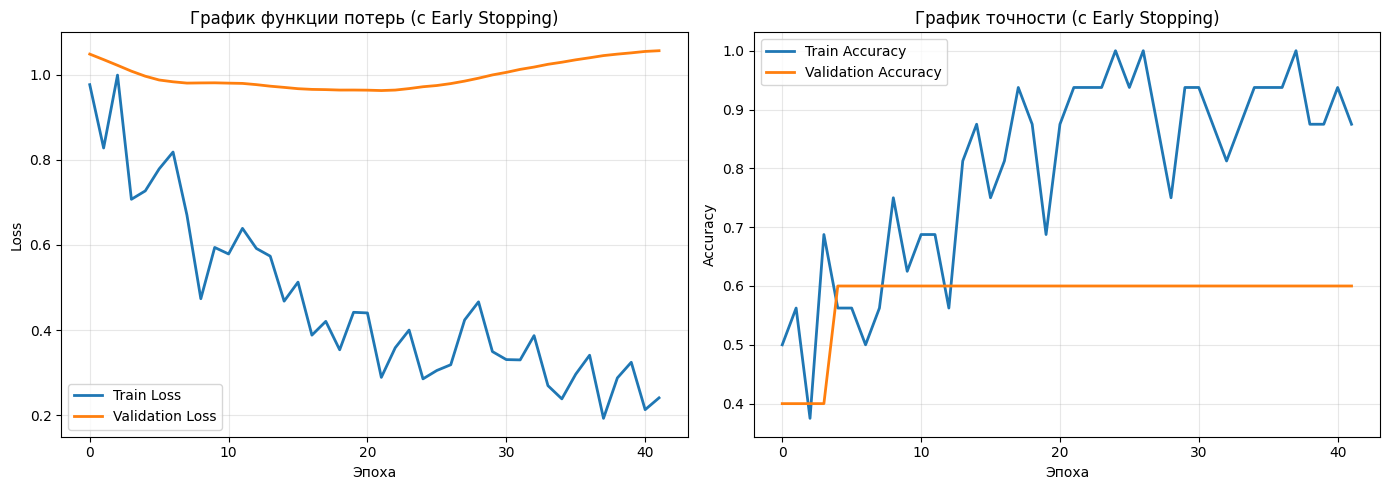

In [33]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history2.history["loss"], label="Train Loss", linewidth=2)
plt.plot(history2.history["val_loss"], label="Validation Loss", linewidth=2)
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("График функции потерь (с Early Stopping)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history2.history["accuracy"], label="Train Accuracy", linewidth=2)
plt.plot(history2.history["val_accuracy"], label="Validation Accuracy", linewidth=2)
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("График точности (с Early Stopping)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

DROPOUT - это метод регуляризации, который во время обучения случайно "отключает" часть нейронов. Это заставляет сеть учиться более устойчивым признакам, а не запоминать конкретные примеры.

EARLY STOPPING - останавливает обучение, когда модель перестаёт улучшаться на валидационных данных. Если validation loss не улучшается N эпох подряд (patience) - обучение прекращается. Это, по идее, предотвращает переобучение: модель не успевает "зазубрить" тренировочные данные.

## Мультиклассовая классификация

In [21]:
print(f"МУЛЬТИКЛАССОВАЯ КЛАССИФИКАЦИЯ\n")

X_all = vectorizer.fit_transform(df["text"]).toarray()
y_all = df["sentiment"].values

print(f"Всего данных: {len(X_all)}")
print(f"Распределение классов:\n{pd.Series(y_all).value_counts().sort_index()}")


X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_all, y_all, test_size=0.3, random_state=42
)

scaler2 = StandardScaler()
X_train_m = scaler2.fit_transform(X_train_m)
X_test_m = scaler2.transform(X_test_m)

print(f"Train: {len(X_train_m)}, Test: {len(X_test_m)}")

МУЛЬТИКЛАССОВАЯ КЛАССИФИКАЦИЯ

Всего данных: 40
Распределение классов:
0    15
1    15
2    10
Name: count, dtype: int64
Train: 28, Test: 12


# Модель для мультиклассовой классификации

In [93]:
model3 = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_m.shape[1],)),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(3, activation="softmax"),
])

model3.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss", 
    patience=10, 
    restore_best_weights=True 
)

print("Архитектура модели:")
model3.summary()

Архитектура модели:


C:\Users\danii\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_96 (Dense)                     │ (None, 64)                  │           6,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_20 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_97 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_98 (Dense)                     │ (None, 3)                   │              99 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,643 (33.76 KB)

 Trainable params: 8,643 (33.76 KB)

 Non-trainable params: 0 (0.00 B)

## Обучение

In [94]:
history3 = model3.fit(
    X_train_m, y_train_m,
    epochs=150,
    batch_size=8,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

print(f"\nОбучение остановилось на эпохе: {len(history3.history['loss'])}")

Epoch 1/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.2727 - loss: 1.5382 - val_accuracy: 0.1667 - val_loss: 0.9469
Epoch 2/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3636 - loss: 1.3918 - val_accuracy: 0.5000 - val_loss: 0.9250
Epoch 3/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.3182 - loss: 1.1553 - val_accuracy: 0.6667 - val_loss: 0.9039
Epoch 4/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.3636 - loss: 1.1366 - val_accuracy: 0.6667 - val_loss: 0.8929
Epoch 5/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5455 - loss: 1.1389 - val_accuracy: 0.6667 - val_loss: 0.8872
Epoch 6/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5455 - loss: 0.9769 - val_accuracy: 0.6667 - val_loss: 0.8826
Epoch 7/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5909 - loss: 0.8590 - val_accuracy: 0.5000 - val_loss: 0.8779
Epoch 8/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7727 - loss: 0.7258 - val_accuracy: 0.5000 - val_loss:

In [95]:
y_pred_m = np.argmax(model3.predict(X_test_m), axis=1)

print(f"РЕЗУЛЬТАТЫ МУЛЬТИКЛАССОВОЙ КЛАССИФИКАЦИИ\n")

print(f"F1-Score (weighted):  {f1_score(y_test_m, y_pred_m, average='weighted'):.4f}")
print(f"Precision (weighted): {precision_score(y_test_m, y_pred_m, average='weighted'):.4f}")
print(f"Recall (weighted):    {recall_score(y_test_m, y_pred_m, average='weighted'):.4f}")


print("\nF1-Score по классам:")
for i, score in enumerate(f1_score(y_test_m, y_pred_m, average=None)):
    class_name = ["Негативный", "Позитивный", "Нейтральный"][i]
    print(f"  Класс {i} ({class_name}): {score:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
РЕЗУЛЬТАТЫ МУЛЬТИКЛАССОВОЙ КЛАССИФИКАЦИИ

F1-Score (weighted):  0.6571
Precision (weighted): 0.6667
Recall (weighted):    0.6667

F1-Score по классам:
  Класс 0 (Негативный): 0.6667
  Класс 1 (Позитивный): 0.5714
  Класс 2 (Нейтральный): 0.8000


## Визуализация обучения

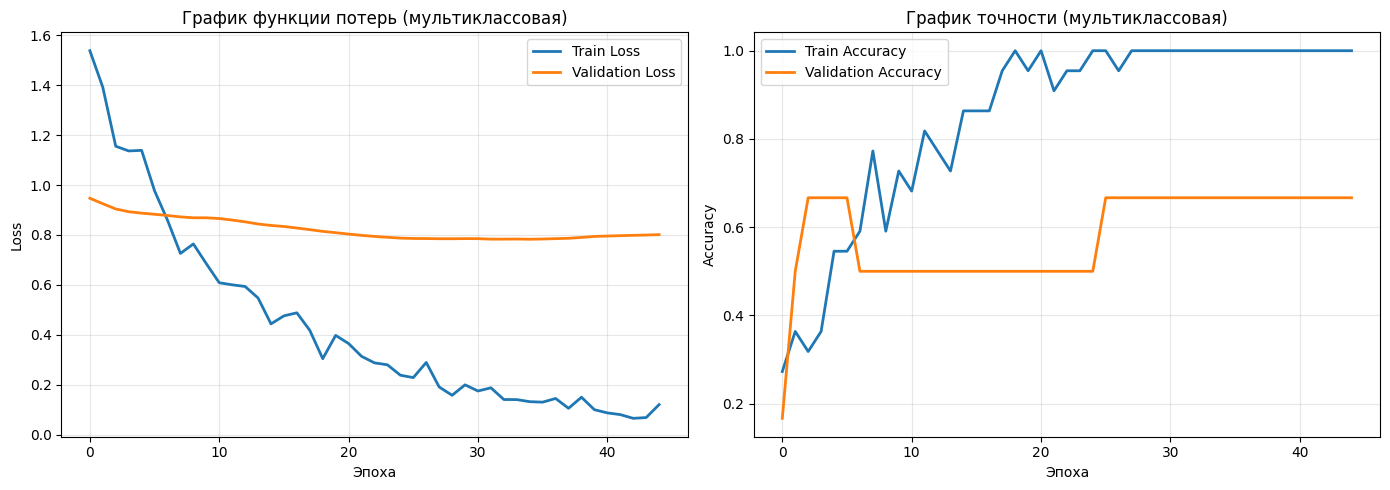

In [96]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history3.history["loss"], label="Train Loss", linewidth=2)
plt.plot(history3.history["val_loss"], label="Validation Loss", linewidth=2)
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("График функции потерь (мультиклассовая)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history3.history["accuracy"], label="Train Accuracy", linewidth=2)
plt.plot(history3.history["val_accuracy"], label="Validation Accuracy", linewidth=2)
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("График точности (мультиклассовая)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Модель работает - определяет тональность в 2 случаях из 3. Лучше всего ей дается нейтральная тональность, хуже - позитивная. Учитывая микродатасет, результат я считаю неплохой.

## Сравнение архитектур

In [97]:
print(f"СРАВНЕНИЕ АРХИТЕКТУР\n")

configs = {
    "16": [16],
    "32-16": [32, 16],
    "64-32-16": [64, 32, 16],
    "128-64-32-16": [128, 64, 32, 16],
}

results = []

for name, layers_list in configs.items():
    print(f"\nОбучение архитектуры: {name}")
    
    m = Sequential()
    m.add(Dense(layers_list[0], activation="relu", input_shape=(X_train.shape[1],)))
    
    for size in layers_list[1:]:
        m.add(Dense(size, activation="relu"))
    
    m.add(Dense(1, activation="sigmoid"))
    m.compile(optimizer="adam", loss="binary_crossentropy")
    m.fit(X_train, y_train, epochs=80, batch_size=8, verbose=0)
    
    y_pred_a = (m.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
    
    results.append({
        "Архитектура": name,
        "F1": round(f1_score(y_test, y_pred_a), 4),
        "Precision": round(precision_score(y_test, y_pred_a), 4),
        "Recall": round(recall_score(y_test, y_pred_a), 4),
    })
    
    print(f"F1: {results[-1]['F1']}")

results_df = pd.DataFrame(results)
print(f"СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ\n")
print(results_df.to_string(index=False))

СРАВНЕНИЕ АРХИТЕКТУР


Обучение архитектуры: 16


C:\Users\danii\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


F1: 0.5

Обучение архитектуры: 32-16


C:\Users\danii\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


F1: 0.4

Обучение архитектуры: 64-32-16


C:\Users\danii\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


F1: 0.5714

Обучение архитектуры: 128-64-32-16


C:\Users\danii\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


F1: 0.4444
СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ

 Архитектура     F1  Precision  Recall
          16 0.5000     0.4000  0.6667
       32-16 0.4000     0.2857  0.6667
    64-32-16 0.5714     0.5000  0.6667
128-64-32-16 0.4444     0.3333  0.6667


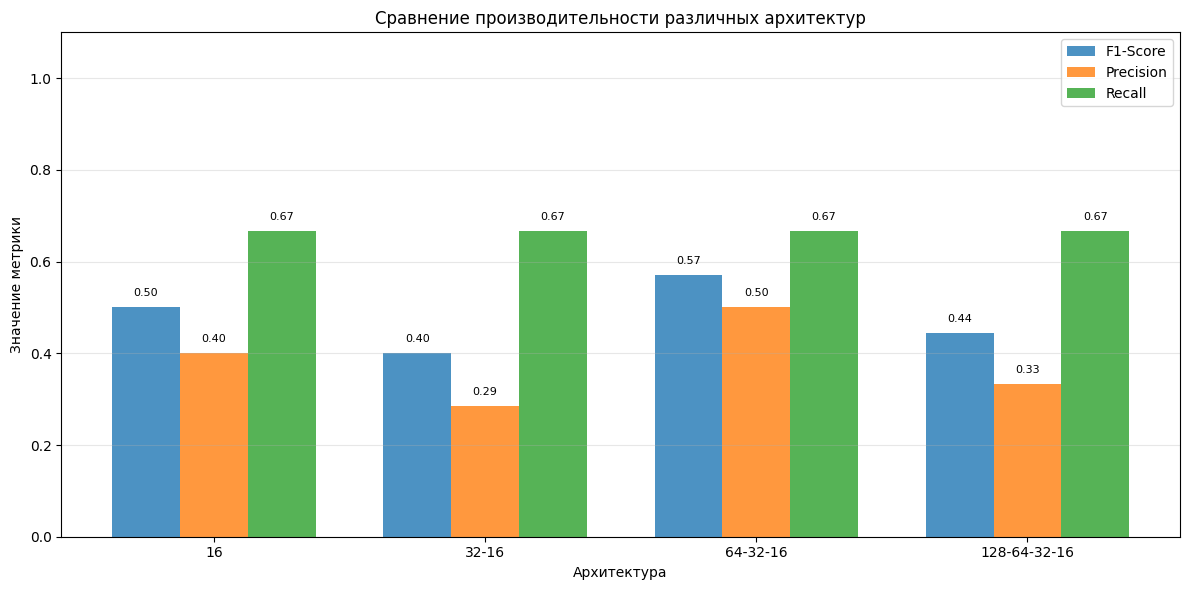

ЛУЧШАЯ АРХИТЕКТУРА: 64-32-16
   F1-Score: 0.5714


In [98]:
plt.figure(figsize=(12, 6))

x = range(len(results_df))
width = 0.25

plt.bar([i - width for i in x], results_df["F1"], width, label="F1-Score", alpha=0.8)
plt.bar([i for i in x], results_df["Precision"], width, label="Precision", alpha=0.8)
plt.bar([i + width for i in x], results_df["Recall"], width, label="Recall", alpha=0.8)

plt.xlabel("Архитектура")
plt.ylabel("Значение метрики")
plt.title("Сравнение производительности различных архитектур")
plt.xticks(x, results_df["Архитектура"])
plt.ylim(0, 1.1)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

for i, row in results_df.iterrows():
    plt.text(i - width, row['F1'] + 0.02, f"{row['F1']:.2f}", 
             ha='center', va='bottom', fontsize=8)
    plt.text(i, row['Precision'] + 0.02, f"{row['Precision']:.2f}", 
             ha='center', va='bottom', fontsize=8)
    plt.text(i + width, row['Recall'] + 0.02, f"{row['Recall']:.2f}", 
             ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

best_arch = results_df.iloc[results_df["F1"].idxmax()]["Архитектура"]
best_f1 = results_df["F1"].max()

print(f"ЛУЧШАЯ АРХИТЕКТУРА: {best_arch}")
print(f"   F1-Score: {best_f1}")

Почему больше нейронов ≠ лучше: Слишком большая сеть запоминает тренировочные данные вместо того, чтобы учиться общим закономерностям.

fit() - это обучение: модель смотрит на данные с правильными ответами и настраивает свои параметры. predict() - это применение: уже обученная модель смотрит на новые данные и выдаёт предсказания.